# Глава 2. От октября к ноябрю: проверка исходных рядов

**LEO West · W_R4_C-4 · D1/D2/D3 · ноябрь 2017**  
Dimitri Bolt · 25.09.2026 · **Исходные данные проверены; сравнение фаз предстоит**

[Оглавление](README.md) · [Назад: глава 1](01_october_2017.ipynb) · [Подробные проверки](details/02_data_checks.md)

**Цель главы:** проверить, сохраняются ли октябрьские амплитуды и фазовые сдвиги
$A_j(W),\phi_j(W),\Delta_{jk}(W)$ в ноябре. Первый шаг выявил особенности записей,
которые надо учесть до подгонки модели.

## 2.1. Ноябрьские данные

Интервал **[01.11.2017, 01.12.2017)**, местное время базы. Те же датчики
**994 / 1010 / 1026**; по **10 582 записи** на каждый, всего **31 746**.
Кодов ошибки $\leq -9999$ нет. Все исходные значения, повторы и временные метки сохранены.

[Данные и происхождение](data/ch02/README.md) · [Код и запуск](details/02_data_checks.md#запуск-и-следующий-шаг)

In [1]:
from pathlib import Path
import sys
project = next(p for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "Project_description/Research_log/chapter02.py").is_file())
if str(project) not in sys.path:
    sys.path.insert(0, str(project))
from Project_description.Research_log.chapter02 import load_november
report = load_november()

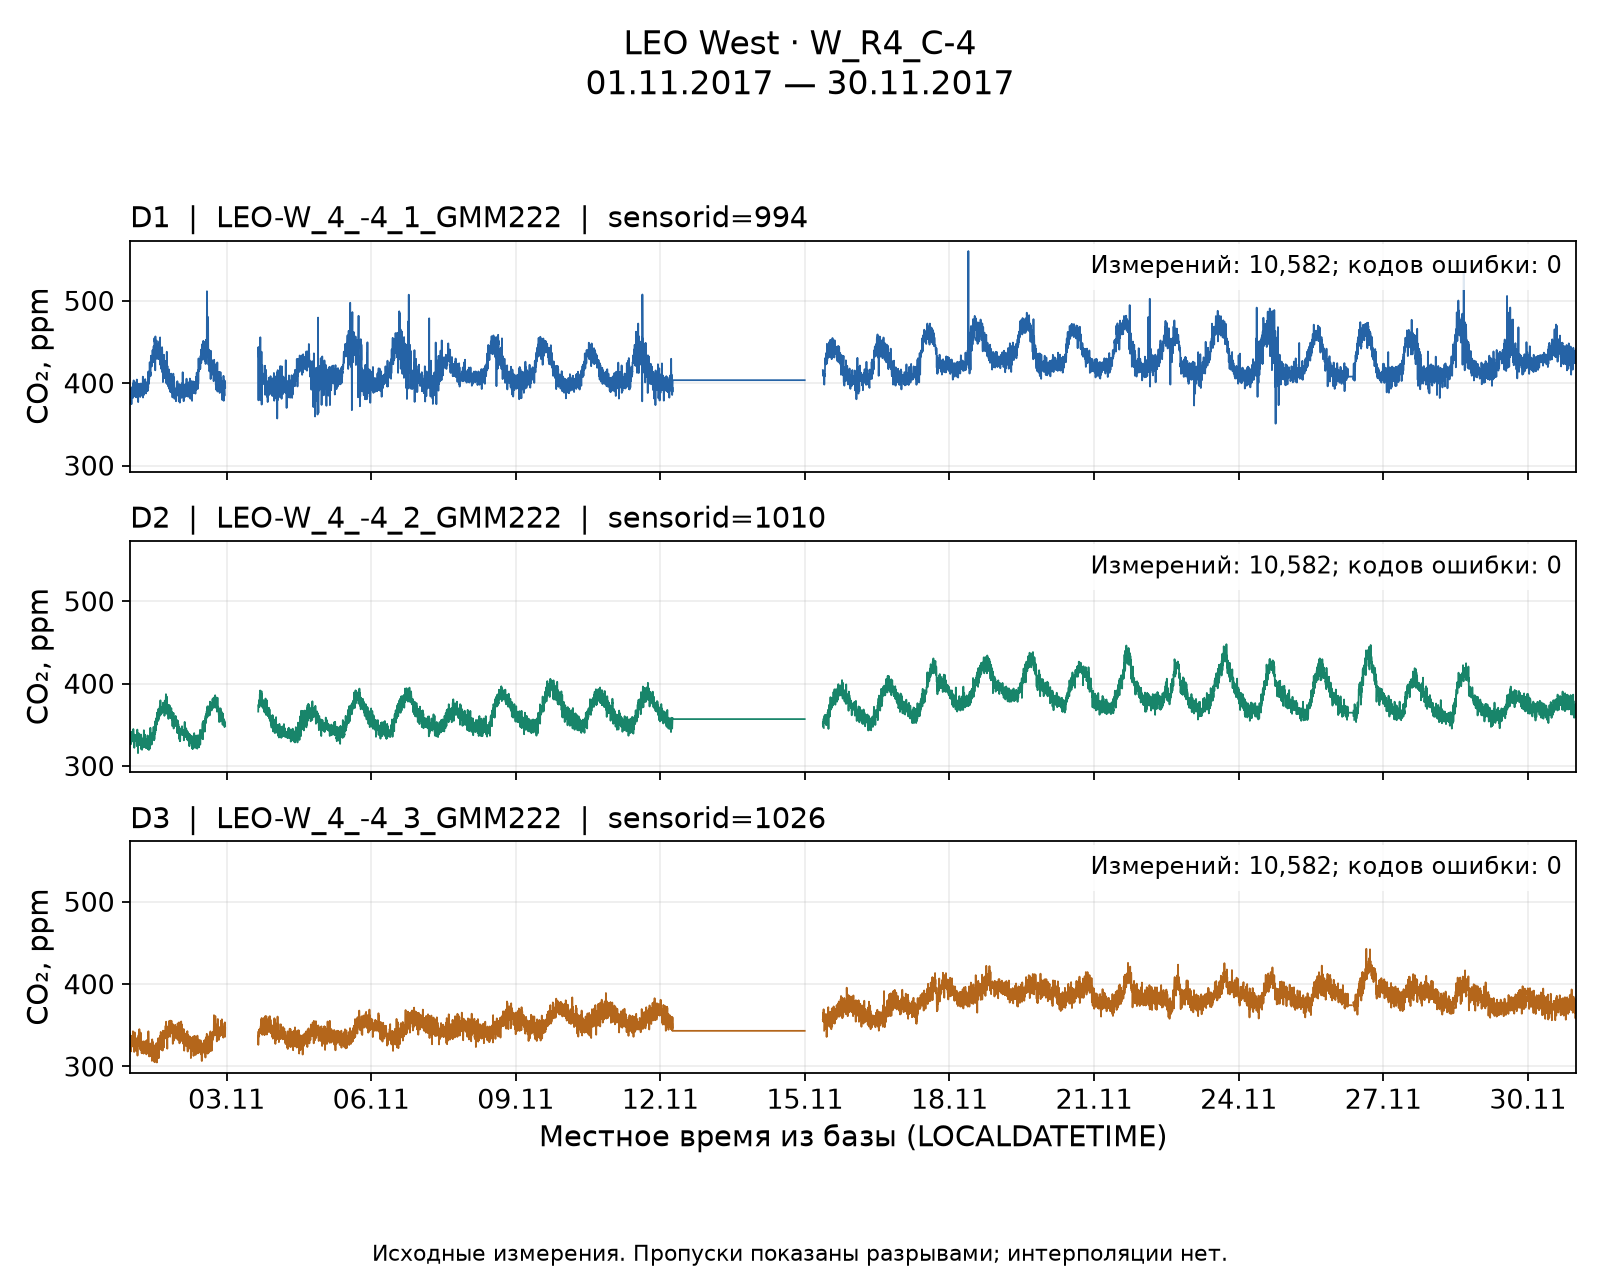

In [2]:
report.show("raw")

**Рисунок 2.1.** Три исходных ряда на общей временной шкале. Пропуски разрывают линию;
прямой участок 12–14 ноября состоит из реально записанных постоянных значений.
Интерполяция не выполнялась.

## 2.2. Неравномерное число записей

В каждом ряду есть **2262 интервала длиной 0–10 секунд** между соседними записями;
медиана положительного шага — **299 секунд**. В октябрьском снимке интервалов 0–10 секунд не было.
С 7 по 14 ноября число записей достигает 514–533 в сутки, 30 ноября — 519.
Более частые записи при одинаковых весах сильнее влияют на среднее и МНК.

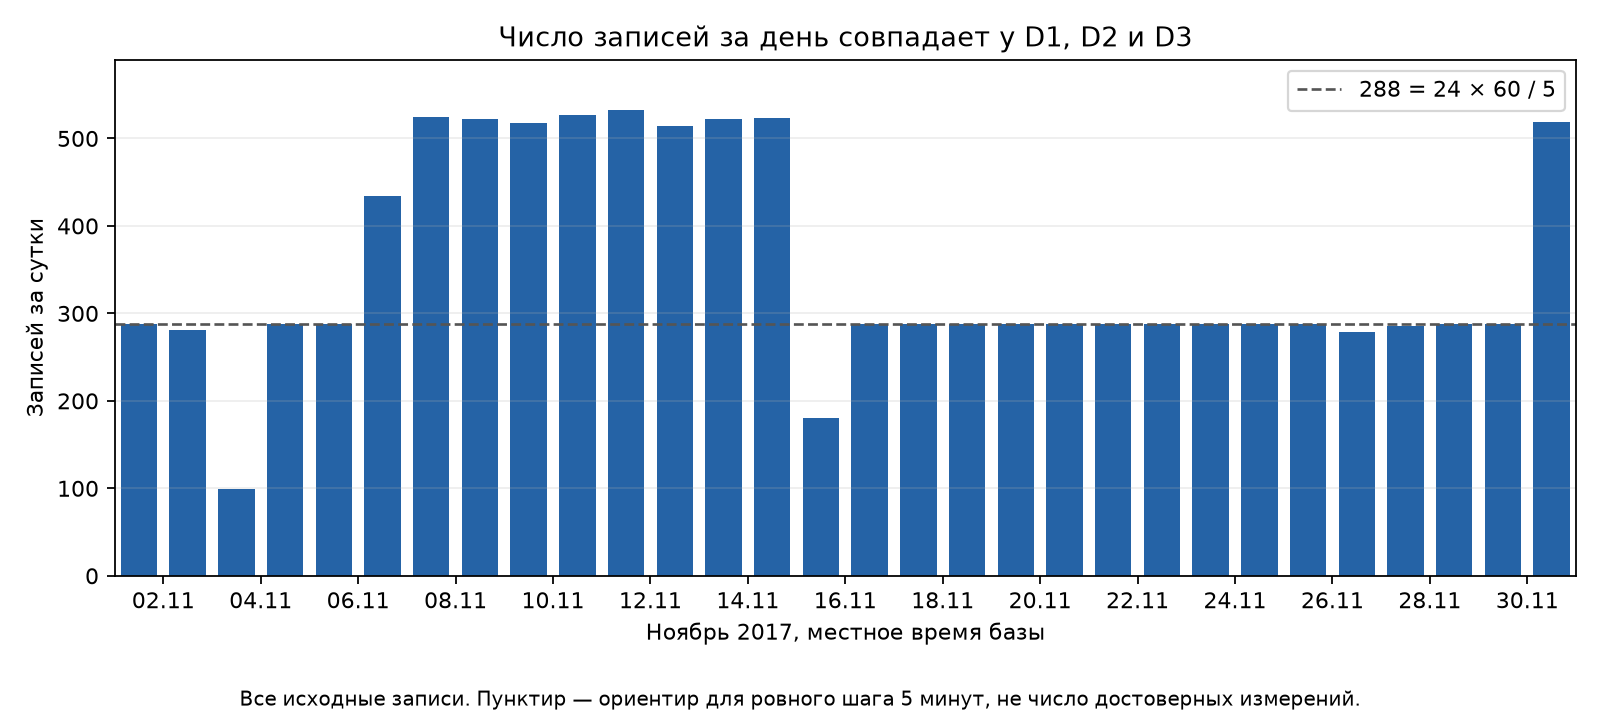

In [3]:
report.show("counts")

**Рисунок 2.2.** Суточное число записей одинаково у трёх датчиков.
Пунктир $288=24\cdot60/5$ — ориентир для равномерного шага 5 минут.
Увеличение числа строк само по себе не означает увеличение количества независимой информации.

[Подробно о шаге и пропусках](details/02_data_checks.md#шаг-и-число-записей)

## 2.3. Залипание датчиков

**Принятое рабочее правило:** выявленные длительные участки неизменных показаний
считаем периодами неработоспособности и исключаем из последующего анализа.
Это правило принято по уточнению Димитрия о критерии Габитова.

У D1/D2/D3 совпадают два таких интервала:

- **12.11.2017 06:10:04 — 14.11.2017 23:55:08:** 65,75 часа, по 1435 записей
  на датчик. Значения D1/D2/D3: **403,657 / 356,967 / 343,271 ppm**.
- **26.11.2017 06:25:05 — 26.11.2017 08:25:03:** около 2 часов,
  по 25 записей на датчик.

Каждый датчик повторяет своё значение. Исходная выгрузка сохраняется;
исключение будет применено к рядам, используемым в расчёте.
[Границы участков и метод обнаружения](details/02_data_checks.md#постоянные-участки).

> **Примечание для обсуждения с Габитовым.** В базе есть повторные временные метки,
> иногда с разными значениями CO₂. Способ их обработки пока не выбран.
> [Подробности](details/02_data_checks.md#повторные-временные-метки).


## 2.4. Ближайший маленький шаг

**Получено:** ноябрьские исходные ряды; для двух интервалов залипания принято
правило исключения. Ноябрьские амплитуды, R² и фазовые сдвиги ещё не рассчитаны.

**Далее:** построить три ряда D1/D2/D3, выделить оба интервала залипания цветом
и показать разрывы на их месте в ряду для анализа. Исходные значения сохраняются;
исключённые записи не заменяются нулями и не интерполируются.

Результат этого шага — один рисунок, на котором видно, какие участки исключены.
После его просмотра перейдём к следующему действию.

[Оглавление](README.md) · [Глава 1](01_october_2017.ipynb) ·
[Подробные проверки](details/02_data_checks.md) · [Дальнейший план](PLAN.md#chapter-2)
